# Задание 3. Деревья решений в игрушечной задаче

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = (10, 8)
import collections

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree

In [2]:
# Создание датафрейма с dummy variables
def create_df(dic, feature_list):
    out = pd.DataFrame(dic)
    out = pd.concat([out, pd.get_dummies(out[feature_list])], axis = 1)
    out.drop(feature_list, axis = 1, inplace = True)
    return out

# Некоторые значения признаков есть в тесте, но нет в трейне и наоборот
def intersect_features(train, test):
    common_feat = list( set(train.keys()) & set(test.keys()))
    return train[common_feat], test[common_feat]

In [3]:
features = ['Внешность', 'Алкоголь_в_напитке',
            'Уровень_красноречия', 'Потраченные_деньги']

In [4]:
df_train = {}
df_train['Внешность'] = ['приятная', 'приятная', 'приятная', 'отталкивающая',
                          'отталкивающая', 'отталкивающая', 'приятная']
df_train['Алкоголь_в_напитке'] = ['да', 'да', 'нет', 'нет', 'да', 'да', 'да']
df_train['Уровень_красноречия'] = ['высокий', 'низкий', 'средний', 'средний',
                                    'низкий', 'высокий', 'средний']
df_train['Потраченные_деньги'] = ['много', 'мало', 'много', 'мало', 'много',
                                   'много', 'много']
df_train['Поедет'] = [0, 1, 0, 1, 1, 0, 0]

df_train = create_df(df_train, features)
df_train

,Поедет,Внешность_отталкивающая,Внешность_приятная,Алкоголь_в_напитке_да,Алкоголь_в_напитке_нет,Уровень_красноречия_высокий,Уровень_красноречия_низкий,Уровень_красноречия_средний,Потраченные_деньги_мало,Потраченные_деньги_много
0,0,False,True,True,False,True,False,False,False,True
1,1,False,True,True,False,False,True,False,True,False
2,0,False,True,False,True,False,False,True,False,True
3,1,True,False,False,True,False,False,True,True,False
4,1,True,False,True,False,False,True,False,False,True
5,0,True,False,True,False,True,False,False,False,True
6,0,False,True,True,False,False,False,True,False,True


In [5]:
df_test = {}
df_test['Внешность'] = ['приятная', 'приятная', 'отталкивающая']
df_test['Алкоголь_в_напитке'] = ['нет', 'да', 'да']
df_test['Уровень_красноречия'] = ['низкий', 'высокий', 'средний']
df_test['Потраченные_деньги'] = ['много', 'мало', 'много']
df_test['Поедет'] = [0, 1, 0]

df_test = create_df(df_test, features)
df_test

,Поедет,Внешность_отталкивающая,Внешность_приятная,Алкоголь_в_напитке_да,Алкоголь_в_напитке_нет,Уровень_красноречия_высокий,Уровень_красноречия_низкий,Уровень_красноречия_средний,Потраченные_деньги_мало,Потраченные_деньги_много
0,0,False,True,False,True,False,True,False,False,True
1,1,False,True,True,False,True,False,False,True,False
2,0,True,False,True,False,False,False,True,False,True


In [6]:
y = df_train['Поедет']
y_test = df_test['Поедет']

In [7]:
df_train, df_test = intersect_features(train=df_train, test=df_test)
df_train

,Внешность_приятная,Поедет,Уровень_красноречия_средний,Уровень_красноречия_низкий,Внешность_отталкивающая,Алкоголь_в_напитке_да,Уровень_красноречия_высокий,Алкоголь_в_напитке_нет,Потраченные_деньги_много,Потраченные_деньги_мало
0,True,0,False,False,False,True,True,False,True,False
1,True,1,False,True,False,True,False,False,False,True
2,True,0,True,False,False,False,False,True,True,False
3,False,1,True,False,True,False,False,True,False,True
4,False,1,False,True,True,True,False,False,True,False
5,False,0,False,False,True,True,True,False,True,False
6,True,0,True,False,False,True,False,False,True,False


In [8]:
treeClassifier = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=17)

In [9]:
treeClassifier.fit(df_train, y)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,17
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Вопрос 1. Какое качество на обучающей выборке (доля верных ответов) имеет дерево решений, обученное с ограничением max_depth=3? Округлите ответ до 2 знаков после запятой.
> 1.0

In [10]:
accuracy_score(y, treeClassifier.predict(df_train))

1.0

Вопрос 2. Какое качество на тестовой выборке имеет дерево решений, обученное с ограничением max_depth=3? Округлите ответ до 2 знаков после запятой.
> 0.67

In [11]:
accuracy_score(y_test, treeClassifier.predict(df_test))

1.0

## Визуализация дерева решений

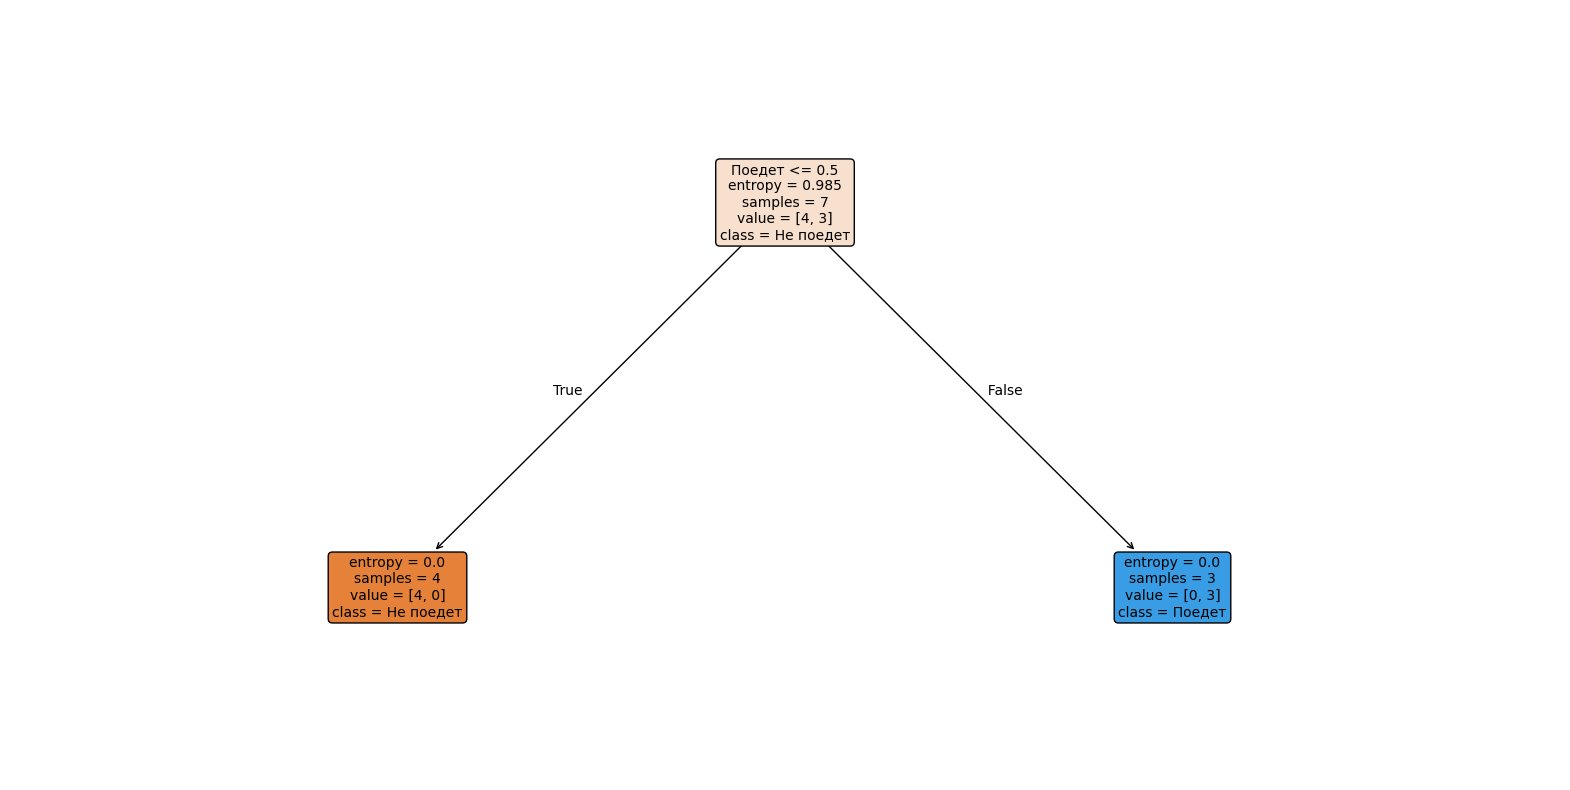

In [12]:
# Визуализация дерева решений с использованием matplotlib (не требует Graphviz)
plt.figure(figsize=(20, 10))
plot_tree(treeClassifier, 
          feature_names=df_train.columns,
          class_names=['Не поедет', 'Поедет'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.savefig('decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

## Расчет энтропии и прироста информации

In [13]:
balls = [1 for i in range(9)] + [0 for i in range(11)]

In [14]:
balls_left  = [1 for i in range(8)] + [0 for i in range(5)] # 8 синих и 5 желтых
balls_right = [1 for i in range(1)] + [0 for i in range(6)] # 1 синий и 6 желтых

In [15]:
def entropy(a_list):
    _, probabilities = np.unique(a_list, return_counts=True)
    probabilities = probabilities / len(a_list)
    sum = np.sum(-probabilities * np.log(probabilities))
    return sum

In [16]:
print(entropy(balls)) # 9 синих и 11 желтых
print(entropy(balls_left)) # 8 синих и 5 желтых
print(entropy(balls_right)) # 1 синий и 6 желтых
print(entropy([1,2,3,4,5,6])) # энтропия игральной кости с несмещенным центром тяжести

0.6881388137135884
0.666278442414676
0.410116318288409
1.7917594692280547


Вопрос 3. Чему равна энтропия состояния, заданного списком balls_left?
> 0.66

Вопрос 4. Чему равна энтропия игральной кости с несмещенным центром тяжести?
> 1.79

In [17]:
def information_gain(root, left, right):
    ''' root - изначальный набор данных, left и right два разбиения изначального набора'''
    return entropy(root) - len(left) * entropy(left) / len(root)  - len(right) / len(root) * entropy(right)

In [18]:
information_gain(balls, balls_left, balls_right)

np.float64(0.11151711474310591)

Вопрос 5. Каков прирост информации при разделении выборки на balls_left и balls_right?
> 0.11

In [19]:
def best_feature_to_split(X, y):
    ''' Выводит прирост информации при разбиении по каждому признаку'''
    information_gains = []
    
    for feature_name in X.columns:
        feature_values = X[feature_name]
        unique_values = np.unique(feature_values)
        
        # Для каждого возможного значения признака создаем разбиение
        best_gain = -1
        
        for value in unique_values:
            # Создаем маски для левого и правого подмножеств
            left_mask = feature_values <= value  # Можно использовать == для категориальных
            right_mask = ~left_mask
            
            left_y = y[left_mask]
            right_y = y[right_mask]
            
            # Вычисляем прирост информации для этого разбиения
            gain = information_gain(y, left_y, right_y)
            
            if gain > best_gain:
                best_gain = gain
        
        information_gains.append((feature_name, best_gain))
    
    return information_gains

In [20]:
best_feature_to_split(df_train, y)

[('Внешность_приятная', np.float64(0.08878194993480432)),
 ('Поедет', np.float64(0.6829081047004717)),
 ('Уровень_красноречия_средний', np.float64(0.014032215111297541)),
 ('Уровень_красноречия_низкий', np.float64(0.32547780217319466)),
 ('Внешность_отталкивающая', np.float64(0.08878194993480437)),
 ('Алкоголь_в_напитке_да', np.float64(0.004143433819589815)),
 ('Уровень_красноречия_высокий', np.float64(0.20218548540814563)),
 ('Алкоголь_в_напитке_нет', np.float64(0.004143433819589842)),
 ('Потраченные_деньги_много', np.float64(0.32547780217319466)),
 ('Потраченные_деньги_мало', np.float64(0.32547780217319466))]